Acurácia modelo linear: 0.560
Acurácia MLP (2→8→1):  0.560

Espaço original: R² — XOR não-separável
Espaço oculto:   R⁸ — MLP aprendeu representação separável


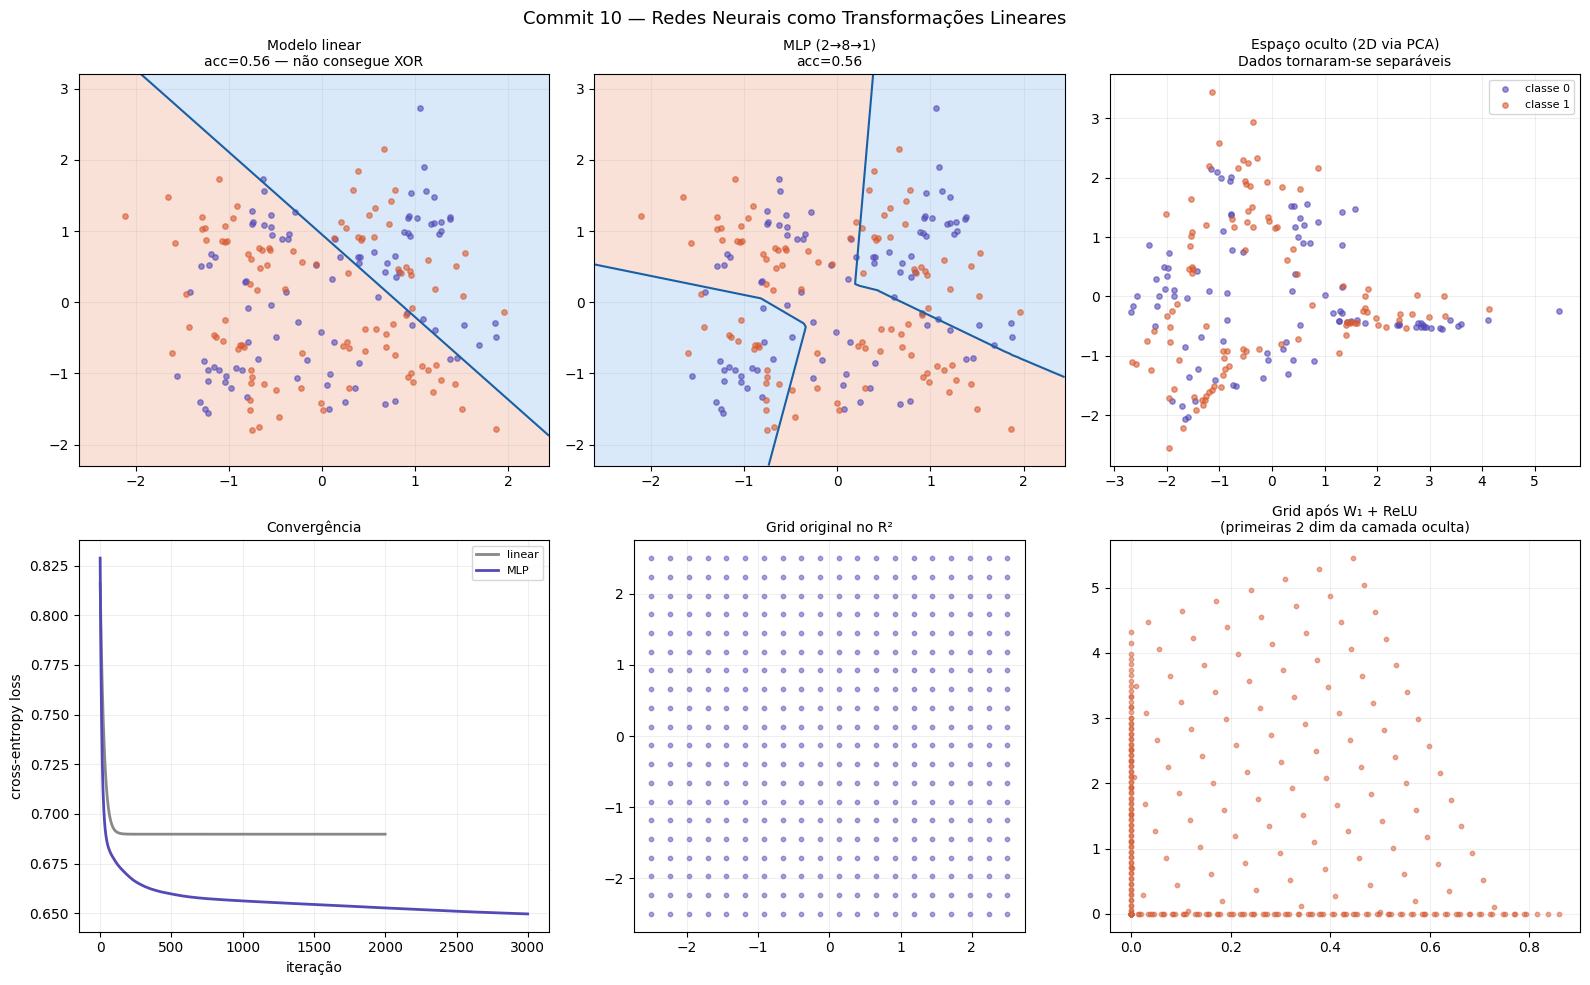

In [2]:
# TEORIA:
# Uma rede neural é:
#   f(x) = Wₗ σ(Wₗ₋₁ σ(... W₁x + b₁ ...) + bₗ₋₁) + bₗ
#
# Sem a ativação não-linear σ, ela colapsa:
#   Wₗ(Wₗ₋₁(...W₁x)) = (Wₗ Wₗ₋₁...W₁) x = W_efetivo x
# Uma composição de lineares é linear. Profundidade sem σ = inútil.
#
# O que cada camada FAZ geometricamente:
#
# 1. Camada linear Wx + b:
#    - Rotação + escala (W)
#    - Translação (b)
#    Em R²: transforma paralelogramos em paralelogramos.
#
# 2. ReLU(z) = max(0, z):
#    - Dobra o espaço: zera metade
#    - Cria não-linearidade: fronteiras lineares por partes
#
# 3. Composição de camadas:
#    - Cada camada rotaciona/escala/dobra o espaço
#    - Iterativamente, dados não-linearmente separáveis
#      se tornam linearmente separáveis na representação final
#
# TEOREMA DA APROXIMAÇÃO UNIVERSAL:
# Uma rede com 1 camada oculta e suficientes neurônios pode
# aproximar qualquer função contínua em R^n.
# MAS: redes profundas aprendem representações hierárquicas
# muito mais eficientemente do que redes largas e rasas.
#
# GEOMETRIA DO ESPAÇO DE FEATURES:
# A última camada oculta é um "espaço de representação".
# O classificador final é hiperplano linear nesse espaço.
# A rede aprendeu a tornar os dados linearmente separáveis.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ============================================================
# PARTE 1 — Por que linearidade pura não funciona
# ============================================================

np.random.seed(42)

# XOR: o problema mais simples que é não-linearmente separável
n = 200
X_xor = np.random.randn(n, 2) * 0.5
y_xor = ((X_xor[:, 0] > 0) ^ (X_xor[:, 1] > 0)).astype(float)
# separar em 4 quadrantes com sinal alternado
X_xor += np.column_stack([
    np.where(y_xor == 0, -0.8, 0.8) * np.sign(np.random.randn(n)),
    np.where(y_xor == 0, -0.8, 0.8) * np.sign(np.random.randn(n))
])

# regressão logística (modelo linear) vs MLP
def sigmoid(z): return 1. / (1. + np.exp(-z))
def sigmoid_d(z): s = sigmoid(z); return s*(1-s)
def relu(z): return np.maximum(0., z)
def relu_d(z): return (z > 0.).astype(float)

class RedeSimples:
    """MLP leve: apenas para demonstração geométrica."""
    def __init__(self, dims, ativacao=relu):
        self.dims = dims
        self.L = len(dims) - 1
        self.ativ = ativacao
        self.ativ_d = relu_d if ativacao is relu else sigmoid_d
        self.W = []
        self.b = []
        for i in range(self.L):
            n_in, n_out = dims[i], dims[i+1]
            self.W.append(np.random.randn(n_out, n_in) * np.sqrt(2./n_in))
            self.b.append(np.zeros(n_out))

    def forward(self, X, guardar=False):
        a = X.T
        ativacoes = [a]
        zs = []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = W @ a + b[:, None]
            zs.append(z)
            a = sigmoid(z) if i == self.L-1 else self.ativ(z)
            ativacoes.append(a)
        return a.T, ativacoes, zs

    def predict(self, X):
        out, _, _ = self.forward(X)
        return (out[:, 0] > 0.5).astype(int)

    def treinar_sgd(self, X, y, alpha=0.05, n_iter=3000):
        hist = []
        n = len(y)
        for it in range(n_iter):
            out, ativs, zs = self.forward(X, guardar=True)
            loss = -np.mean(y*np.log(out[:,0]+1e-8) + (1-y)*np.log(1-out[:,0]+1e-8))
            hist.append(loss)

            # backward
            delta = (out[:,0] - y)[:, None].T   # (1, n)
            grads_W = []
            grads_b = []
            for i in reversed(range(self.L)):
                a_prev = ativs[i]
                if i < self.L - 1:
                    delta = delta * self.ativ_d(zs[i])
                dW = delta @ a_prev.T / n
                db = delta.mean(axis=1)
                grads_W.insert(0, dW)
                grads_b.insert(0, db)
                delta = self.W[i].T @ delta

            for i in range(self.L):
                self.W[i] -= alpha * grads_W[i]
                self.b[i] -= alpha * grads_b[i]
        return hist

# modelo linear (1 camada, sem oculta)
modelo_linear = RedeSimples([2, 1], ativacao=sigmoid)
hist_linear = modelo_linear.treinar_sgd(X_xor, y_xor, alpha=0.1, n_iter=2000)
acc_linear = np.mean(modelo_linear.predict(X_xor) == y_xor.astype(int))

# MLP com 1 camada oculta
np.random.seed(42)
modelo_mlp = RedeSimples([2, 8, 1], ativacao=relu)
hist_mlp = modelo_mlp.treinar_sgd(X_xor, y_xor, alpha=0.05, n_iter=3000)
acc_mlp = np.mean(modelo_mlp.predict(X_xor) == y_xor.astype(int))

print(f"Acurácia modelo linear: {acc_linear:.3f}")
print(f"Acurácia MLP (2→8→1):  {acc_mlp:.3f}")

# ============================================================
# PARTE 2 — Representação interna: espaço da camada oculta
# ============================================================
# Vamos ver como a camada oculta transforma os dados XOR
# de não-separáveis para separáveis linearmente.

# extrair ativações da camada oculta
_, ativs_mlp, _ = modelo_mlp.forward(X_xor)
repr_oculta = ativs_mlp[1].T    # shape (n, 8)

print(f"\nEspaço original: R² — XOR não-separável")
print(f"Espaço oculto:   R⁸ — MLP aprendeu representação separável")

# PCA do espaço oculto para visualizar em 2D
repr_c = repr_oculta - repr_oculta.mean(axis=0)
_, _, Vt_repr = np.linalg.svd(repr_c, full_matrices=False)
repr_2d = repr_c @ Vt_repr[:2].T

# ============================================================
# PARTE 3 — Transformação geométrica camada por camada
# ============================================================
# Vamos rastrear como um grid de pontos é transformado
# por cada camada da rede.

# grid de pontos no espaço de entrada
g = np.linspace(-2.5, 2.5, 20)
gx, gy = np.meshgrid(g, g)
grid = np.column_stack([gx.ravel(), gy.ravel()])

# aplicar cada camada manualmente
grid_apos_W1 = grid @ modelo_mlp.W[0][:2, :].T   # projeção nas 2 primeiras dim
grid_apos_relu = np.maximum(0, grid_apos_W1)       # relu

# ============================================================
# PARTE 4 — VISUALIZAÇÃO
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Commit 10 — Redes Neurais como Transformações Lineares", fontsize=13)

def fronteira_decisao(modelo, ax, X, y, titulo):
    h = 0.05
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                          np.arange(y_min, y_max, h))
    grid_pts = np.c_[xx.ravel(), yy.ravel()]
    out, _, _ = modelo.forward(grid_pts)
    Z = out[:, 0].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1],
                colors=['#B5D4F4', '#F5C4B3'], alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0.5], colors=['#185FA5'], linewidths=1.5)
    ax.scatter(X[y==0, 0], X[y==0, 1], s=15, alpha=0.6, color='#534AB7')
    ax.scatter(X[y==1, 0], X[y==1, 1], s=15, alpha=0.6, color='#D85A30')
    ax.set_title(titulo, fontsize=10)
    ax.grid(True, alpha=0.2)

fronteira_decisao(modelo_linear, axes[0, 0], X_xor, y_xor,
                  f'Modelo linear\nacc={acc_linear:.2f} — não consegue XOR')
fronteira_decisao(modelo_mlp, axes[0, 1], X_xor, y_xor,
                  f'MLP (2→8→1)\nacc={acc_mlp:.2f}')

# representação interna 2D
axes[0, 2].scatter(repr_2d[y_xor==0, 0], repr_2d[y_xor==0, 1],
                    s=15, alpha=0.6, color='#534AB7', label='classe 0')
axes[0, 2].scatter(repr_2d[y_xor==1, 0], repr_2d[y_xor==1, 1],
                    s=15, alpha=0.6, color='#D85A30', label='classe 1')
axes[0, 2].set_title("Espaço oculto (2D via PCA)\nDados tornaram-se separáveis", fontsize=10)
axes[0, 2].legend(fontsize=8); axes[0, 2].grid(True, alpha=0.2)

# loss curves
axes[1, 0].plot(hist_linear, color='#888', lw=2, label='linear')
axes[1, 0].plot(hist_mlp, color='#534AB7', lw=2, label='MLP')
axes[1, 0].set_xlabel("iteração"); axes[1, 0].set_ylabel("cross-entropy loss")
axes[1, 0].set_title("Convergência", fontsize=10)
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(True, alpha=0.2)

# grid original
axes[1, 1].scatter(grid[:, 0], grid[:, 1], s=10, alpha=0.5, color='#534AB7')
axes[1, 1].set_title("Grid original no R²", fontsize=10)
axes[1, 1].set_aspect('equal'); axes[1, 1].grid(True, alpha=0.2)

# grid após W1 e ReLU (2 primeiras dims)
axes[1, 2].scatter(grid_apos_relu[:, 0], grid_apos_relu[:, 1],
                    s=10, alpha=0.5, color='#D85A30')
axes[1, 2].set_title("Grid após W₁ + ReLU\n(primeiras 2 dim da camada oculta)", fontsize=10)
axes[1, 2].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('assets/10_neural_networks_geometry.png', dpi=150, bbox_inches='tight')
plt.show()